survey_results_public.csv (49,191 rows)
        ↓
STEP 1  : Load Dataset
        ↓
STEP 2  : Filter & Mapping DevType → 21 Label Karir
        ↓
STEP 3  : Cleaning Fitur Skill (all_skills, tools, databases)
        ↓
STEP 4  : Cleaning Fitur Numerik & Kategorikal
        ↓
STEP 5  : Drop Duplikat & Baris Tanpa Skill
        ↓
STEP 6  : Susun Kolom Final
        ↓
STEP 7  : Validasi & Distribusi Label
        ↓
STEP 8  : Simpan dataset_so_clean.csv (pre-SMOTE) ← TEKS ORIGINAL
        ↓
STEP 9  : Feature Engineering (Numeric only - untuk SMOTE)
        ↓
STEP 10 : Train-Test Split (80/20, Stratified)
        ↓
STEP 11 : Feature Scaling (untuk SMOTE)
        ↓
STEP 12 : SMOTE (hanya pada training set)
        ↓
STEP 13 : Simpan dataset_so_smote_balanced.csv ← TEKS ORIGINAL (BALANCED)
        ↓
STEP 14 : Visualisasi Distribusi Dataset

In [1]:
import pandas as pd
import numpy as np
import warnings
import os
import random
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


In [2]:
PATH_SO     = "survey_results_public.csv"
PATH_CLEAN  = "dataset_so_clean.csv"
PATH_SMOTE  = "dataset_so_smote_balanced.csv"

SO_COLS = [
    'DevType',
    'LanguageHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'DatabaseHaveWorkedWith',
    'PlatformHaveWorkedWith',
    'DevEnvsHaveWorkedWith',
    'YearsCode',
    'EdLevel',
]

print(f"Input  : {PATH_SO}")
print(f"Output : {PATH_CLEAN}, {PATH_SMOTE}")

Input  : survey_results_public.csv
Output : dataset_so_clean.csv, dataset_so_smote_balanced.csv


In [3]:
SO_DEVTYPE_TO_CAREER = {
    "Developer, front-end": "Frontend Developer",
    "Developer, back-end": "Backend Developer",
    "Developer, full-stack": "Full Stack Developer",
    "Developer, mobile": "Mobile App Developer",
    "Developer, game or graphics": "Game Developer",
    "Developer, desktop or enterprise applications": "Backend Developer",
    "Developer, embedded applications or devices": "Backend Developer",
    "Architect, software or solutions": "Backend Developer",
    "Data or business analyst": "Data Analyst",
    "Data engineer": "Data Engineer",
    "Data scientist": "Data Scientist",
    "AI/ML engineer": "Machine Learning Engineer",
    "Developer, AI apps or physical AI": "Machine Learning Engineer",
    "Applied scientist": "Machine Learning Engineer",
    "Cloud infrastructure engineer": "Cloud Engineer",
    "DevOps engineer or professional": "DevOps Engineer",
    "System administrator": "System Administrator",
    "Cybersecurity or InfoSec professional": "Cybersecurity Analyst",
    "Database administrator or engineer": "Database Administrator (DBA)",
    "UX, Research Ops or UI design professional": "UX Designer",
    "Developer, QA or test": "QA Engineer",
    "Support engineer or analyst": "IT Support Specialist",
    "Product manager": "Product Manager (Teknologi)",
}

EDLEVEL_MAP = {
    "Primary/elementary school": 0,
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 1,
    "Some college/university study without earning a degree": 2,
    "Associate degree (A.A., A.S., etc.)": 3,
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)": 4,
    "Master's degree (M.A., M.S., M.Eng., MBA, etc.)": 5,
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": 6,
    "Other (please specify):": 2,
}

print(f"✅ {len(set(SO_DEVTYPE_TO_CAREER.values()))} label karir siap")

✅ 18 label karir siap


In [4]:
def split_semicolon(val):
    if not isinstance(val, str) or pd.isna(val):
        return []
    return [v.strip() for v in val.split(';') if v.strip()]

def normalize_skill(skill):
    return skill.strip().lower()

def get_primary_devtype(devtype_str):
    types = split_semicolon(devtype_str)
    for t in types:
        if t in SO_DEVTYPE_TO_CAREER:
            return t
    return None

def merge_all_skills(row, skill_cols):
    combined = set()
    for col in skill_cols:
        val = row.get(col, '')
        for skill in split_semicolon(str(val) if pd.notna(val) else ''):
            normalized = normalize_skill(skill)
            if normalized:
                combined.add(normalized)
    return ';'.join(sorted(combined))

def clean_years_code(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip()
    if 'less than 1' in val_str.lower():
        return 0.0
    if 'more than 50' in val_str.lower():
        return 50.0
    try:
        return float(val_str)
    except ValueError:
        return np.nan

print("✅ Helper functions siap")

✅ Helper functions siap


In [5]:
print("=" * 65)
print("STEP 1 : LOADING DATASET")
print("=" * 65)

df_so = pd.read_csv(PATH_SO, usecols=SO_COLS, low_memory=False)

print(f"\n  Rows loaded    : {len(df_so):,}")
print(f"  Columns        : {list(df_so.columns)}")
print(f"\n  Missing values per kolom:")
for col in df_so.columns:
    n = df_so[col].isna().sum()
    print(f"    {col:<35}: {n:>6,} ({n/len(df_so)*100:.1f}%)")

STEP 1 : LOADING DATASET

  Rows loaded    : 49,191
  Columns        : ['EdLevel', 'YearsCode', 'DevType', 'LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith', 'DevEnvsHaveWorkedWith']

  Missing values per kolom:
    EdLevel                            :  1,042 (2.1%)
    YearsCode                          :  6,149 (12.5%)
    DevType                            :  5,511 (11.2%)
    LanguageHaveWorkedWith             : 17,520 (35.6%)
    DatabaseHaveWorkedWith             : 23,641 (48.1%)
    PlatformHaveWorkedWith             : 24,933 (50.7%)
    WebframeHaveWorkedWith             : 26,199 (53.3%)
    DevEnvsHaveWorkedWith              : 23,172 (47.1%)


In [6]:
print("\n" + "=" * 65)
print("STEP 2 : FILTER & MAPPING DEVTYPE → LABEL KARIR")
print("=" * 65)

before = len(df_so)
df_so = df_so.dropna(subset=['DevType']).copy()
print(f"\n  [2.1] Drop baris tanpa DevType   : {before:,} → {len(df_so):,} rows")

df_so['DevType_primary'] = df_so['DevType'].apply(get_primary_devtype)

before = len(df_so)
df_so = df_so.dropna(subset=['DevType_primary']).copy()
print(f"  [2.2] Drop DevType tidak relevan : {before:,} → {len(df_so):,} rows")

df_so['career_label'] = df_so['DevType_primary'].map(SO_DEVTYPE_TO_CAREER)
before = len(df_so)
df_so = df_so.dropna(subset=['career_label']).copy()
print(f"  [2.3] Drop unmapped career label : {before:,} → {len(df_so):,} rows")

print(f"\n  Distribusi awal label karir:")
dist = df_so['career_label'].value_counts()
for career, count in dist.items():
    bar = "█" * min(count // 30, 35)
    print(f"    {career:<42}: {count:>5}  {bar}")


STEP 2 : FILTER & MAPPING DEVTYPE → LABEL KARIR

  [2.1] Drop baris tanpa DevType   : 49,191 → 43,680 rows
  [2.2] Drop DevType tidak relevan : 43,680 → 34,835 rows
  [2.3] Drop unmapped career label : 34,835 → 34,835 rows

  Distribusi awal label karir:
    Full Stack Developer                      : 12351  ███████████████████████████████████
    Backend Developer                         : 12330  ███████████████████████████████████
    Frontend Developer                        :  1974  ███████████████████████████████████
    Mobile App Developer                      :  1391  ███████████████████████████████████
    Machine Learning Engineer                 :  1210  ███████████████████████████████████
    DevOps Engineer                           :  1053  ███████████████████████████████████
    Data Engineer                             :   770  █████████████████████████
    Data Scientist                            :   574  ███████████████████
    System Administrator                  

In [7]:
print("\n" + "=" * 65)
print("STEP 3 : CLEANING FITUR SKILL")
print("=" * 65)

SKILL_COLS = [
    'LanguageHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'PlatformHaveWorkedWith',
]

df_so['all_skills'] = df_so.apply(
    lambda row: merge_all_skills(row, SKILL_COLS), axis=1
)
print(f"\n  [3.1] all_skills dibuat dari   : {SKILL_COLS}")

df_so['tools'] = df_so['DevEnvsHaveWorkedWith'].apply(
    lambda x: ';'.join(sorted([normalize_skill(s) for s in split_semicolon(str(x))
                                if s])) if pd.notna(x) else ''
)
print(f"  [3.2] tools dibuat dari        : DevEnvsHaveWorkedWith")

df_so['databases'] = df_so['DatabaseHaveWorkedWith'].apply(
    lambda x: ';'.join(sorted([normalize_skill(s) for s in split_semicolon(str(x))
                                if s])) if pd.notna(x) else ''
)
print(f"  [3.3] databases dibuat dari    : DatabaseHaveWorkedWith")

total = len(df_so)
for col in ['all_skills', 'tools', 'databases']:
    filled = (df_so[col] != '').sum()
    print(f"\n  {col:<15}: {filled:,}/{total:,} terisi ({filled/total*100:.1f}%)")


STEP 3 : CLEANING FITUR SKILL

  [3.1] all_skills dibuat dari   : ['LanguageHaveWorkedWith', 'WebframeHaveWorkedWith', 'PlatformHaveWorkedWith']
  [3.2] tools dibuat dari        : DevEnvsHaveWorkedWith
  [3.3] databases dibuat dari    : DatabaseHaveWorkedWith

  all_skills     : 25,804/34,835 terisi (74.1%)

  tools          : 21,181/34,835 terisi (60.8%)

  databases      : 21,426/34,835 terisi (61.5%)


In [8]:
print("\n" + "=" * 65)
print("STEP 4 : CLEANING FITUR NUMERIK & KATEGORIKAL")
print("=" * 65)

df_so['years_code'] = df_so['YearsCode'].apply(clean_years_code)
median_years = df_so['years_code'].median()
before_null = df_so['years_code'].isna().sum()
df_so['years_code'] = df_so['years_code'].fillna(median_years)

print(f"\n  [4.1] YearsCode  : {before_null} NaN diimputasi dengan median ({median_years:.1f})")
print(f"        Range      : {df_so['years_code'].min():.0f} – {df_so['years_code'].max():.0f} tahun")

df_so['education_level'] = df_so['EdLevel'].map(EDLEVEL_MAP)
before_null = df_so['education_level'].isna().sum()
median_edu = df_so['education_level'].median()
df_so['education_level'] = df_so['education_level'].fillna(median_edu)

print(f"  [4.2] EdLevel    : {before_null} NaN diimputasi dengan median ({median_edu:.0f})")
print(f"        Encoding   : 0=SD, 1=SMA, 2=Tanpa gelar, 3=D3, 4=S1, 5=S2, 6=S3")


STEP 4 : CLEANING FITUR NUMERIK & KATEGORIKAL

  [4.1] YearsCode  : 696 NaN diimputasi dengan median (15.0)
        Range      : 1 – 100 tahun
  [4.2] EdLevel    : 25386 NaN diimputasi dengan median (2)
        Encoding   : 0=SD, 1=SMA, 2=Tanpa gelar, 3=D3, 4=S1, 5=S2, 6=S3


In [9]:
print("\n" + "=" * 65)
print("STEP 5 : DROP DUPLIKAT & BARIS TANPA SKILL")
print("=" * 65)

before = len(df_so)
df_so = df_so.drop_duplicates(
    subset=['all_skills', 'tools', 'databases', 'years_code', 'career_label']
).copy()
print(f"\n  [5.1] Drop duplikat         : {before:,} → {len(df_so):,} rows")

before = len(df_so)
df_so = df_so[df_so['all_skills'] != ''].copy()
print(f"  [5.2] Drop baris tanpa skill : {before:,} → {len(df_so):,} rows")


STEP 5 : DROP DUPLIKAT & BARIS TANPA SKILL

  [5.1] Drop duplikat         : 34,835 → 26,504 rows
  [5.2] Drop baris tanpa skill : 26,504 → 25,792 rows


In [10]:
print("\n" + "=" * 65)
print("STEP 6 & 7 : SUSUN FINAL & VALIDASI")
print("=" * 65)

FINAL_COLS = [
    'all_skills',
    'tools',
    'databases',
    'years_code',
    'education_level',
    'career_label',
]

df_final = df_so[FINAL_COLS].copy()
df_final['tools'] = df_final['tools'].fillna('').astype(str)
df_final['databases'] = df_final['databases'].fillna('').astype(str)

print(f"\n  Shape          : {df_final.shape}")

label_dist = df_final['career_label'].value_counts()
total_rows = len(df_final)

print(f"\n  Total rows          : {total_rows:,}")
print(f"  Total karir unik    : {df_final['career_label'].nunique()}")
print(f"  Rasio imbalance     : {label_dist.max() / label_dist.min():.1f}x")
print(f"\n  Distribusi per label:")
for career, count in label_dist.items():
    pct = count / total_rows * 100
    bar = "█" * min(count // 20, 40)
    print(f"    {career:<42}: {count:>5} ({pct:4.1f}%)  {bar}")


STEP 6 & 7 : SUSUN FINAL & VALIDASI

  Shape          : (25792, 6)

  Total rows          : 25,792
  Total karir unik    : 18
  Rasio imbalance     : 138.8x

  Distribusi per label:
    Backend Developer                         :  9300 (36.1%)  ████████████████████████████████████████
    Full Stack Developer                      :  9190 (35.6%)  ████████████████████████████████████████
    Frontend Developer                        :  1418 ( 5.5%)  ████████████████████████████████████████
    Mobile App Developer                      :   945 ( 3.7%)  ████████████████████████████████████████
    Machine Learning Engineer                 :   829 ( 3.2%)  ████████████████████████████████████████
    DevOps Engineer                           :   819 ( 3.2%)  ████████████████████████████████████████
    Data Engineer                             :   576 ( 2.2%)  ████████████████████████████
    Data Scientist                            :   442 ( 1.7%)  ██████████████████████
    System Admi

In [11]:
print("\n" + "=" * 65)
print("STEP 8 : SIMPAN DATASET BERSIH (PRE-SMOTE)")
print("=" * 65)

df_final.to_csv(PATH_CLEAN, index=False, encoding='utf-8')
print(f"\n  ✅ Tersimpan : '{PATH_CLEAN}'")
print(f"     Shape     : {df_final.shape}")
print(f"     Size      : {os.path.getsize(PATH_CLEAN) / 1024:.1f} KB")


STEP 8 : SIMPAN DATASET BERSIH (PRE-SMOTE)

  ✅ Tersimpan : 'dataset_so_clean.csv'
     Shape     : (25792, 6)
     Size      : 5510.7 KB


In [12]:
print("\n" + "=" * 65)
print("STEP 9 : FEATURE ENGINEERING (UNTUK SMOTE)")
print("=" * 65)

def get_skill_vector(skill_str):
    if pd.isna(skill_str) or skill_str == '':
        return 0
    return len([s.strip() for s in str(skill_str).split(';') if s.strip()])

def get_tool_vector(tool_str):
    if pd.isna(tool_str) or tool_str == '':
        return 0
    return len([s.strip() for s in str(tool_str).split(';') if s.strip()])

def get_db_vector(db_str):
    if pd.isna(db_str) or db_str == '':
        return 0
    return len([s.strip() for s in str(db_str).split(';') if s.strip()])

X_numeric = pd.DataFrame({
    'years_code': df_final['years_code'].values,
    'education_level': df_final['education_level'].values,
    'num_skills': df_final['all_skills'].apply(get_skill_vector).values,
    'num_tools': df_final['tools'].apply(get_tool_vector).values,
    'num_databases': df_final['databases'].apply(get_db_vector).values,
})

le = LabelEncoder()
y = le.fit_transform(df_final['career_label'])

print(f"\n  [9.1] Fitur numeric X      : {X_numeric.shape}")
print(f"  [9.2] Label y (encoded)    : {len(y)}")
print(f"  [9.3] Jumlah label karir   : {len(le.classes_)}")
print(f"\n  Label mapping:")
for i, label in enumerate(le.classes_):
    print(f"    {i} → {label}")


STEP 9 : FEATURE ENGINEERING (UNTUK SMOTE)

  [9.1] Fitur numeric X      : (25792, 5)
  [9.2] Label y (encoded)    : 25792
  [9.3] Jumlah label karir   : 18

  Label mapping:
    0 → Backend Developer
    1 → Cloud Engineer
    2 → Cybersecurity Analyst
    3 → Data Analyst
    4 → Data Engineer
    5 → Data Scientist
    6 → Database Administrator (DBA)
    7 → DevOps Engineer
    8 → Frontend Developer
    9 → Full Stack Developer
    10 → Game Developer
    11 → IT Support Specialist
    12 → Machine Learning Engineer
    13 → Mobile App Developer
    14 → Product Manager (Teknologi)
    15 → QA Engineer
    16 → System Administrator
    17 → UX Designer


In [13]:
print("\n" + "=" * 65)
print("STEP 10 : TRAIN-TEST SPLIT")
print("=" * 65)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_numeric, y, np.arange(len(df_final)),
    test_size=0.2,
    stratify=y,
    random_state=42
)

df_train = df_final.iloc[idx_train].reset_index(drop=True)
df_test = df_final.iloc[idx_test].reset_index(drop=True)

print(f"\n  Training set : {len(X_train):,} baris ({len(X_train)/len(X_numeric)*100:.0f}%)")
print(f"  Testing set  : {len(X_test):,} baris ({len(X_test)/len(X_numeric)*100:.0f}%)")


STEP 10 : TRAIN-TEST SPLIT

  Training set : 20,633 baris (80%)
  Testing set  : 5,159 baris (20%)


In [14]:
print("\n" + "=" * 65)
print("STEP 11 : FEATURE SCALING (untuk SMOTE)")
print("=" * 65)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n  Kolom yang di-scaling : years_code, education_level, num_skills, num_tools, num_databases")
print(f"  Scaler fit pada       : training set saja")


STEP 11 : FEATURE SCALING (untuk SMOTE)

  Kolom yang di-scaling : years_code, education_level, num_skills, num_tools, num_databases
  Scaler fit pada       : training set saja


In [15]:
print("\n" + "=" * 65)
print("STEP 12 : SMOTE — OVERSAMPLING (EQUAL DISTRIBUTION)")
print("=" * 65)

# ========== STRATEGI: Oversample SEMUA label ke jumlah yang SAMA ==========

train_dist = Counter(y_train)
max_class_count = max(train_dist.values())  # <- UBAH: ambil MAX, bukan MIN
k_neighbors = min(5, min(train_dist.values()) - 1)

print(f"\n  Kelas terbesar di training set : {max_class_count} sampel")
print(f"  Target oversample semua label  : {max_class_count} sampel")
print(f"  k_neighbors yang digunakan     : {k_neighbors}")

# Buat strategi sampling ratio: semua kelas ke jumlah maksimum
sampling_strategy = {
    label_idx: max_class_count 
    for label_idx in train_dist.keys()
}

print(f"\n  Sampling strategy (label -> target count):")
for label_idx, target_count in sorted(sampling_strategy.items()):
    current_count = train_dist[label_idx]
    diff = target_count - current_count
    print(f"    {le.classes_[label_idx]:<42}: {current_count:>5} → {target_count:>5} (+{diff:>5})")

smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=k_neighbors)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\n  Distribusi training set SEBELUM SMOTE:")
before_dist = Counter(y_train)
for label_idx in sorted(before_dist.keys()):
    print(f"    {le.classes_[label_idx]:<42}: {before_dist[label_idx]:>5}")

print(f"\n  Distribusi training set SETELAH SMOTE:")
after_dist = Counter(y_train_smote)
for label_idx in sorted(after_dist.keys()):
    print(f"    {le.classes_[label_idx]:<42}: {after_dist[label_idx]:>5}")

print(f"\n  Total training sebelum SMOTE : {len(X_train):,}")
print(f"  Total training setelah SMOTE : {len(X_train_smote):,}")
print(f"  ✅ SEMUA LABEL MEMILIKI JUMLAH DATA YANG SAMA: {max_class_count} sampel per karir")

# Buat df_train_smote dengan duplikasi row sesuai distribusi equal
df_train_smote_final = pd.concat(
    [df_train[df_train['career_label'] == le.classes_[label]].sample(
        n=after_dist[label], replace=True, random_state=42
    ) for label in sorted(after_dist.keys())],
    ignore_index=True
)

print(f"\n  DataFrame training post-SMOTE : {len(df_train_smote_final):,} rows")
print(f"  Per karir (equal)             : {len(df_train_smote_final) // len(le.classes_)} baris per label")


STEP 12 : SMOTE — OVERSAMPLING (EQUAL DISTRIBUTION)

  Kelas terbesar di training set : 7440 sampel
  Target oversample semua label  : 7440 sampel
  k_neighbors yang digunakan     : 5

  Sampling strategy (label -> target count):
    Backend Developer                         :  7440 →  7440 (+    0)
    Cloud Engineer                            :   242 →  7440 (+ 7198)
    Cybersecurity Analyst                     :   224 →  7440 (+ 7216)
    Data Analyst                              :   190 →  7440 (+ 7250)
    Data Engineer                             :   461 →  7440 (+ 6979)
    Data Scientist                            :   354 →  7440 (+ 7086)
    Database Administrator (DBA)              :   102 →  7440 (+ 7338)
    DevOps Engineer                           :   655 →  7440 (+ 6785)
    Frontend Developer                        :  1134 →  7440 (+ 6306)
    Full Stack Developer                      :  7352 →  7440 (+   88)
    Game Developer                            :   267 →  74

In [16]:
print("\n" + "=" * 65)
print("STEP 13 : SIMPAN DATASET BALANCED KE CSV")
print("=" * 65)

df_balanced = pd.concat([df_train_smote_final, df_test], ignore_index=True)

df_balanced.to_csv(PATH_SMOTE, index=False, encoding='utf-8')

print(f"\n  ✅ Dataset tersimpan: '{PATH_SMOTE}'")
print(f"     Shape   : {df_balanced.shape}")
print(f"     Size    : {os.path.getsize(PATH_SMOTE) / 1024:.1f} KB")
print(f"\n  Komposisi:")
print(f"     Training (post-SMOTE) : {len(df_train_smote_final):,}")
print(f"     Testing               : {len(df_test):,}")
print(f"     Total                 : {len(df_balanced):,}")


STEP 13 : SIMPAN DATASET BALANCED KE CSV

  ✅ Dataset tersimpan: 'dataset_so_smote_balanced.csv'
     Shape   : (139079, 6)
     Size    : 27838.1 KB

  Komposisi:
     Training (post-SMOTE) : 133,920
     Testing               : 5,159
     Total                 : 139,079



STEP 14 : VISUALISASI DISTRIBUSI DATASET


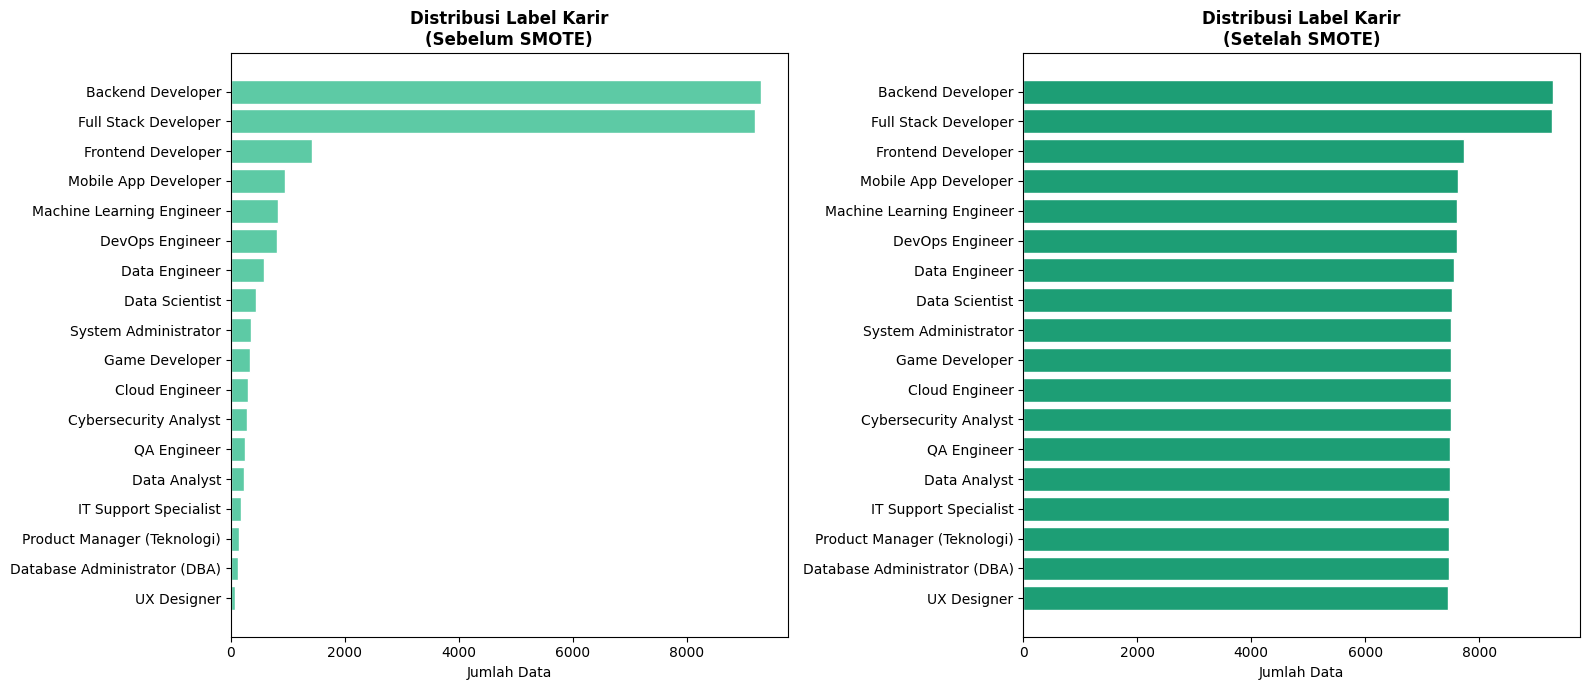


  ✅ Grafik disimpan: distribusi_dataset.png


In [17]:
print("\n" + "=" * 65)
print("STEP 14 : VISUALISASI DISTRIBUSI DATASET")
print("=" * 65)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

counts_before = df_final['career_label'].value_counts()
axes[0].barh(counts_before.index, counts_before.values, color='#5DCAA5', edgecolor='white')
axes[0].set_title('Distribusi Label Karir\n(Sebelum SMOTE)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Data')
axes[0].invert_yaxis()

counts_after = df_balanced['career_label'].value_counts()
axes[1].barh(counts_after.index, counts_after.values, color='#1D9E75', edgecolor='white')
axes[1].set_title('Distribusi Label Karir\n(Setelah SMOTE)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Data')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("distribusi_dataset.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n  ✅ Grafik disimpan: distribusi_dataset.png")

In [18]:
# Load dataset
df = pd.read_csv("dataset_so_smote_balanced.csv")

# Random seed
random.seed(42)
np.random.seed(42)

# Mapping injection
mapping = {
    "Machine Learning Engineer": {
        "skills": [
            "tensorflow", "pytorch", "keras",
            "scikit-learn", "deep learning",
            "computer vision", "nlp",
            "neural networks"
        ],
        "tools": [
            "jupyter notebook",
            "google colab",
            "huggingface"
        ]
    },

    "Data Scientist": {
        "skills": [
            "machine learning",
            "statistical modeling",
            "pandas",
            "numpy",
            "matplotlib",
            "seaborn",
            "data mining"
        ],
        "tools": [
            "rstudio",
            "jupyterlab",
            "knime"
        ]
    },

    "Data Analyst": {
        "skills": [
            "data visualization",
            "exploratory data analysis",
            "dax",
            "business intelligence",
            "google analytics"
        ],
        "tools": [
            "tableau",
            "power bi",
            "microsoft excel",
            "looker"
        ]
    },

    "Data Engineer": {
        "skills": [
            "etl",
            "data warehousing",
            "apache airflow",
            "apache kafka",
            "hadoop",
            "dbt",
            "data pipeline"
        ],
        "tools": [
            "snowflake",
            "databricks",
            "apache spark",
            "talend"
        ]
    },

    "Cybersecurity Analyst": {
        "skills": [
            "penetration testing",
            "ethical hacking",
            "cryptography",
            "network security",
            "malware analysis",
            "vulnerability assessment"
        ],
        "tools": [
            "wireshark",
            "kali linux",
            "burp suite",
            "metasploit",
            "nmap"
        ]
    },

    "Mobile App Developer": {
        "skills": [
            "swift",
            "kotlin",
            "flutter",
            "react native",
            "dart",
            "mobile ui/ux"
        ],
        "tools": [
            "xcode",
            "android studio",
            "emulator"
        ]
    },

    "Game Developer": {
        "skills": [
            "game physics",
            "3d modeling",
            "unity3d",
            "unreal engine",
            "gameplay programming"
        ],
        "tools": [
            "unity editor",
            "unreal editor",
            "blender",
            "godot"
        ]
    },

    "QA Engineer": {
        "skills": [
            "automated testing",
            "selenium",
            "cypress",
            "test-driven development (tdd)",
            "api testing",
            "performance testing"
        ],
        "tools": [
            "postman",
            "jira",
            "selenium webdriver",
            "appium",
            "katalon"
        ]
    },

    "UX Designer": {
        "skills": [
            "wireframing",
            "prototyping",
            "user research",
            "ui design",
            "interaction design",
            "usability testing"
        ],
        "tools": [
            "figma",
            "adobe xd",
            "sketch",
            "invision",
            "miro"
        ]
    }
}

# Function injection
def inject_keywords(existing_text, additions, max_add=3):

    if pd.isna(existing_text):
        existing_items = []
    else:
        existing_items = [
            x.strip().lower()
            for x in str(existing_text).split(";")
            if x.strip()
        ]

    available = [
        x for x in additions
        if x.lower() not in existing_items
    ]

    if not available:
        return "; ".join(existing_items)

    selected = random.sample(
        available,
        random.randint(1, min(max_add, len(available)))
    )

    combined = existing_items + selected
    random.shuffle(combined)

    return "; ".join(dict.fromkeys(combined))

# Process injection
for idx, row in df.iterrows():

    label = row["career_label"]

    if label in mapping:

        # Inject skills
        df.at[idx, "all_skills"] = inject_keywords(
            row["all_skills"],
            mapping[label]["skills"],
            max_add=3
        )

        # Inject tools
        df.at[idx, "tools"] = inject_keywords(
            row["tools"],
            mapping[label]["tools"],
            max_add=2
        )

# Save result
df.to_csv(
    "dataset_so_smote_balanced_injected.csv",
    index=False
)

print("Injection selesai!")

Injection selesai!


In [24]:
'''import pandas as pd

dataset_so_smote_balanced_injected = pd.read_csv('dataset_so_clean.csv')

career_count = (
    dataset_so_smote_balanced_injected['career_label']
    .value_counts()
    .reset_index()
)

career_count.columns = ['career_label', 'jumlah_data']

print(career_count)'''

"import pandas as pd\n\ndataset_so_smote_balanced_injected = pd.read_csv('dataset_so_clean.csv')\n\ncareer_count = (\n    dataset_so_smote_balanced_injected['career_label']\n    .value_counts()\n    .reset_index()\n)\n\ncareer_count.columns = ['career_label', 'jumlah_data']\n\nprint(career_count)"